# 매일 받은 것을 확인한다 — 하루치가 제대로 들어왔나

> `notebooks/01-데이터수집/02.매일받은것을확인한다.ipynb` · 2026-09-02 · 이동원

---

## 이 노트북이 답하는 것

> **"오늘 수집이 돌았다고 하는데, 정말 들어왔나?"**

수집을 매일 자동으로 돌리기 시작하면 실패는 **조용히** 옵니다.
예외가 나면 오히려 다행이고, 무서운 것은 이런 날입니다.

- 배치가 "성공" 이라고 로그를 남겼는데 **0건**이 들어온 날
- 행 수는 그대로인데 **내용이 덮어써진** 날
- 달력에는 거래일인데 **아무도 요청하지 않은** 날

셋 다 예외를 던지지 않습니다. 그래서 **세 각도**로 확인합니다.

| 각도 | 무엇을 보나 | 이것만으로는 못 잡는 것 |
|---|---|---|
| ① **규모** | 행·종목·거래일이 늘었나 | 같은 키를 **덮어쓴** 경우 |
| ② **대장** | 무엇을 언제 받았나 (`fetch_log`) | 기록만 남고 값이 이상한 경우 |
| ③ **품질** | 값이 말이 되나 (`check_data.py`) | — |

**셋이 서로 다른 경로로 같은 사실을 확인**한다는 점이 중요합니다.
하나만 보면 놓치는 자리가 각각 다릅니다.

---

### 오늘의 결론 (2026-09-02 09:15 실행)

| 확인 | 결과 |
|---|---|
| 9월 1일 시세 | **2,765행** 들어옴 (9,220,879 → 9,223,644) |
| 9월 2일 시세 | **0건** — 장이 막 열린 시각이라 아직 없는 것이 정상 |
| 품질 게이트 | ✅ `error` 다섯 항목 전부 0 |


## 0. 준비 — DB 를 **읽기 전용**으로 연다

⚠️ **`mode=ro` 로 엽니다.** 그냥 열면 노트북이 쓰기 주체가 되고, 수집 배치가 도는
중이라면 잠금을 다툽니다. 실제로 이 노트북을 만들던 중에도 DART 수집이 백그라운드로
돌고 있었습니다. 보기만 할 것이므로 쓰기 권한을 가질 이유가 없습니다.

한글 폰트도 여기서 맞춥니다. 안 맞추면 그래프의 한글이 **네모(□□□)** 로 나옵니다.


In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager

# ── 한글 폰트 ──────────────────────────────────────────────
# 설치된 것 중 먼저 찾아지는 것을 쓴다. 사람마다 OS 가 달라 하나로 못 박으면
# 누군가의 화면에서 네모가 뜬다.
설치됨 = {f.name for f in font_manager.fontManager.ttflist}
for 후보 in ("Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"):
    if 후보 in 설치됨:
        plt.rcParams["font.family"] = 후보
        break
plt.rcParams["axes.unicode_minus"] = False   # 마이너스가 네모로 나오는 것을 막는다
plt.rcParams["figure.dpi"] = 110

# ── DB ────────────────────────────────────────────────────
# 저장소 루트 기준 상대 경로. 절대 경로를 찍으면 사람마다 다르고,
# 이 저장소는 PUBLIC 이라 남의 폴더 구조까지 커밋된다.
DB = Path("../../data/krx_cache.db")
con = sqlite3.connect(f"file:{DB}?mode=ro", uri=True)


def 표(sql: str, params=()) -> pd.DataFrame:
    return pd.read_sql_query(sql, con, params=params)


print(f"DB 크기 : {DB.stat().st_size / 1024 / 1024:,.0f} MB")
print(f"폰트    : {plt.rcParams['font.family'][0]}")

DB 크기 : 1,524 MB
폰트    : Malgun Gothic


## 1. 지금 어디까지 차 있나

가장 먼저 볼 것은 **각 표의 마지막 날짜**입니다.
시세와 지수는 **같은 거래일까지** 차 있어야 합니다 — 한쪽만 최신이면
그날 수집이 반쪽만 돈 것입니다.


In [2]:
현황 = 표("""
SELECT 'daily_price(시세)' AS 표,
       COUNT(*)                AS 행수,
       COUNT(DISTINCT code)    AS 종목수,
       COUNT(DISTINCT bas_dd)  AS 거래일,
       MIN(bas_dd)             AS 시작일,
       MAX(bas_dd)             AS 최신일
FROM daily_price
UNION ALL
SELECT 'index_price(지수)',
       COUNT(*), COUNT(DISTINCT index_name), COUNT(DISTINCT bas_dd),
       MIN(bas_dd), MAX(bas_dd)
FROM index_price
""")
현황

,표,행수,종목수,거래일,시작일,최신일
0,daily_price(시세),9223644,3677,4102,20100104,20260901
1,index_price(지수),196119,51,4102,20100104,20260901


In [3]:
# 두 표의 최신일이 같은지 — 다르면 그날 수집이 반쪽만 돈 것이다
최신 = 현황.set_index("표")["최신일"]
같은가 = 최신.nunique() == 1
print(f"시세 최신일 : {최신['daily_price(시세)']}")
print(f"지수 최신일 : {최신['index_price(지수)']}")
print(f"→ {'✅ 같습니다' if 같은가 else '🔴 다릅니다 — 한쪽만 받았습니다'}")

시세 최신일 : 20260901
지수 최신일 : 20260901
→ ✅ 같습니다


## 2. 16년치가 고르게 있나 — 연도별로 본다

한 해가 통째로 비거나 유난히 얇으면 그 구간은 학습에서 편향을 만듭니다.
연도별 거래일 수는 **대체로 245~250일**이어야 합니다.


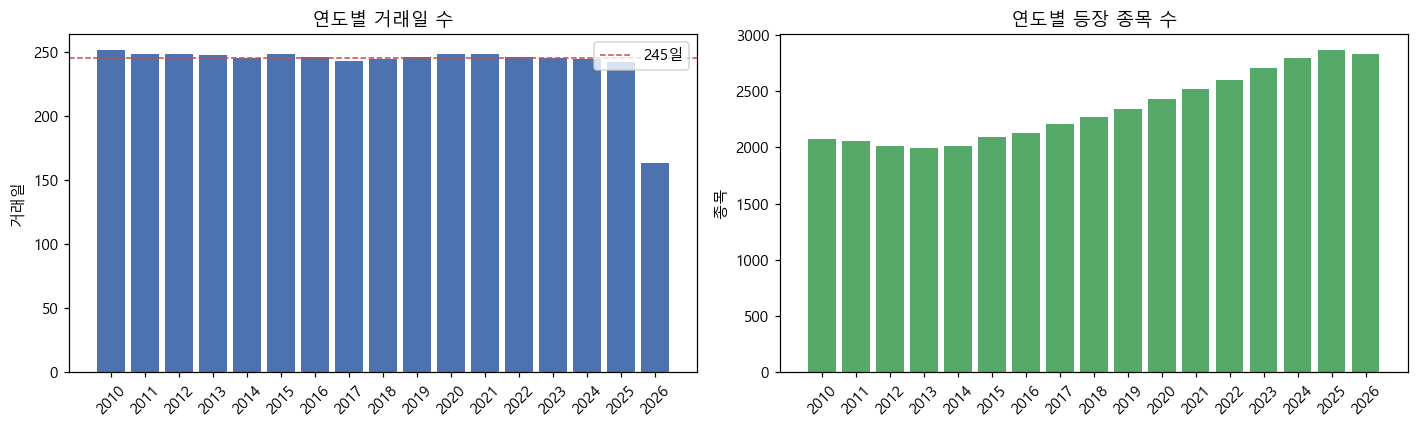

거래일 최소 163일 · 최대 251일
⚠️ 맨 오른쪽 해가 짧은 것은 정상입니다 — 아직 안 끝난 해입니다.


In [4]:
연도별 = 표("""
SELECT SUBSTR(bas_dd, 1, 4) AS 연도,
       COUNT(DISTINCT bas_dd) AS 거래일,
       COUNT(*)               AS 행수,
       COUNT(DISTINCT code)   AS 종목수
FROM daily_price
GROUP BY 연도 ORDER BY 연도
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(연도별["연도"], 연도별["거래일"], color="#4C72B0")
axes[0].axhline(245, color="#C44E52", linestyle="--", linewidth=1, label="245일")
axes[0].set_title("연도별 거래일 수", fontsize=12)
axes[0].set_ylabel("거래일")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].bar(연도별["연도"], 연도별["종목수"], color="#55A868")
axes[1].set_title("연도별 등장 종목 수", fontsize=12)
axes[1].set_ylabel("종목")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"거래일 최소 {연도별['거래일'].min()}일 · 최대 {연도별['거래일'].max()}일")
print("⚠️ 맨 오른쪽 해가 짧은 것은 정상입니다 — 아직 안 끝난 해입니다.")

**종목 수가 오른쪽으로 갈수록 느는 것**이 중요합니다.
지금 상장된 종목만 남기면 *생존 편향*이 생깁니다 — 망한 회사를 빼고 백테스트하면
성과가 실제보다 부풀어 오릅니다. 수업 자료
(`learning/09-finance-ml-dl/1.금융머신러닝.ipynb`)가 말하는 그 편향입니다.

우리 DB 는 **중도 상장폐지된 종목까지** 들고 있어서, 어느 시점으로 잘라도 그때
살아 있던 종목만 볼 수 있습니다.


## 3. ① 규모 — 행 수만 세면 안 되는 이유

"어제보다 2,765행 늘었으니 됐다" 는 **불완전한 검증**입니다.

`daily_price` 의 기본키는 `(bas_dd, code)` 이고 저장은 `INSERT OR REPLACE` 입니다.
같은 날짜·같은 종목을 다시 넣으면 **행 수는 그대로인 채 내용만 바뀝니다.**
행 수를 세는 검증은 이걸 **원리상** 못 잡습니다.

그래서 **날짜별 종목 수**를 함께 봅니다. 종목 수가 갑자기 줄면 그날 응답이 잘린 것입니다.


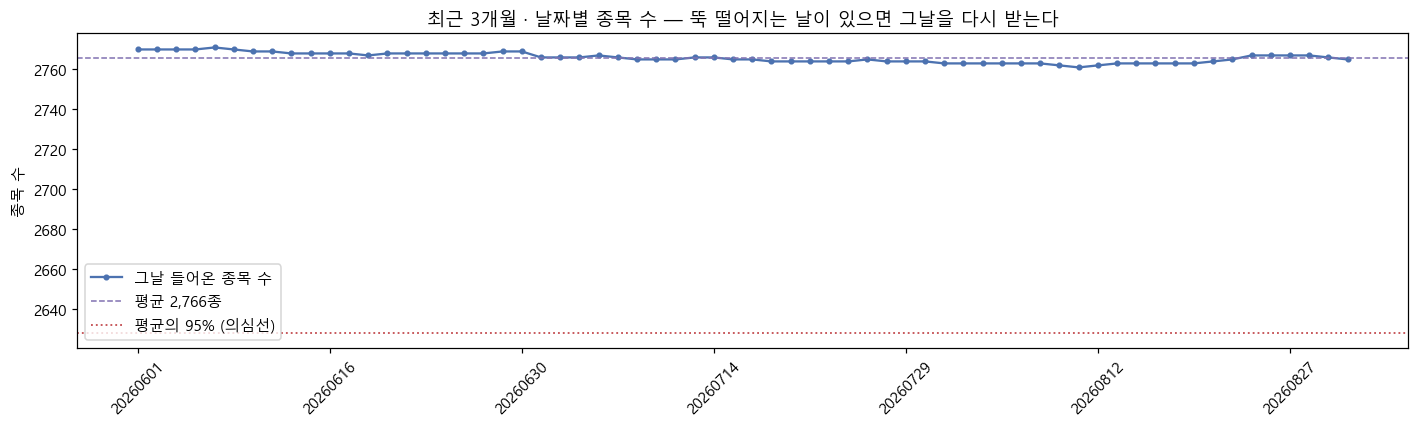

의심선 아래로 떨어진 날: 0일


In [5]:
최근 = 표("""
SELECT bas_dd AS 기준일, COUNT(*) AS 종목수,
       SUM(CASE WHEN close IS NULL OR close = 0 THEN 1 ELSE 0 END) AS 종가없음
FROM daily_price
WHERE bas_dd >= '20260601'
GROUP BY bas_dd ORDER BY bas_dd
""")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(len(최근)), 최근["종목수"], marker="o", markersize=3,
        color="#4C72B0", label="그날 들어온 종목 수")

평균 = 최근["종목수"].mean()
ax.axhline(평균, color="#8172B2", linestyle="--", linewidth=1,
           label=f"평균 {평균:,.0f}종")
# 평균의 95% 아래로 떨어지면 응답이 잘렸을 수 있다
ax.axhline(평균 * 0.95, color="#C44E52", linestyle=":", linewidth=1.2,
           label="평균의 95% (의심선)")

ax.set_title("최근 3개월 · 날짜별 종목 수 — 뚝 떨어지는 날이 있으면 그날을 다시 받는다",
             fontsize=12)
ax.set_ylabel("종목 수")
자리 = range(0, len(최근), 10)
ax.set_xticks(list(자리))
ax.set_xticklabels([최근["기준일"].iloc[i] for i in 자리], rotation=45)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

의심 = 최근[최근["종목수"] < 평균 * 0.95]
print(f"의심선 아래로 떨어진 날: {len(의심)}일")
if len(의심):
    print(의심.to_string(index=False))

`종가없음` 이 섞여 있는 것은 **오류가 아닙니다** — 거래정지 표시행은 시·고·저가가
0 으로 옵니다. 그 판단 근거는 `scripts/check_data.py` 가 설명합니다.


## 4. ② 대장 — 0건은 휴장인가, 아직 안 올라온 것인가

이 구별이 자동 수집의 **핵심**입니다.

- **휴장일**은 영원히 0건입니다 → 다시 요청하면 낭비입니다
- **오늘·어제의 0건**은 *아직 안 올라온 것*일 수 있습니다 → 다시 받아야 합니다

⚠️ 실측: 장 마감은 15:30 인데 **2026-09-01 16:04 에 그날 자료를 요청하니 0행**이었습니다.
KRX 는 확정 시세를 저녁에 올립니다. 이때 0건을 "휴장" 으로 굳혀 버리면 그 하루를
**영원히 잃습니다.**

그래서 `ingest/store/krx_store.py` 는 이렇게 둡니다.

```python
ZERO_ROW_RETRY_DAYS = 7   # 최근 7일 안의 0건은 건너뛰지 않고 다시 확인한다
```


In [6]:
대장 = 표("""
SELECT bas_dd AS 기준일, rows AS 받은행수, fetched_at AS 받은시각
FROM fetch_log ORDER BY bas_dd DESC LIMIT 12
""")
대장

,기준일,받은행수,받은시각
0,20260902,0,2026-09-02T09:42:33
1,20260901,2765,2026-09-02T09:42:39
2,20260831,2766,2026-09-01T16:04:21
3,20260828,2767,2026-09-01T16:04:20
4,20260827,2767,2026-09-01T16:04:17
5,20260826,2767,2026-09-01T16:04:19
6,20260825,2767,2026-08-26T09:36:48
7,20260824,2765,2026-08-26T09:36:45
8,20260821,2764,2026-08-26T09:36:45
9,20260820,2763,2026-08-26T09:36:45


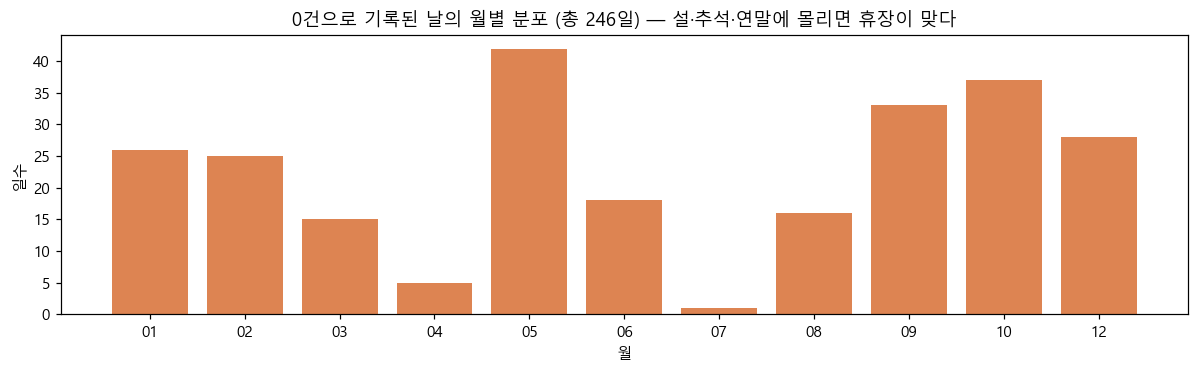

0건 총 246일 · 가장 최근 5일:
20260902
20260817
20260717
20260603
20260525


In [7]:
# 0건인 날이 16년 동안 몇 개이고 언제였나 — 휴장일이면 연말연시·명절에 몰린다
영건 = 표("""
SELECT bas_dd, SUBSTR(bas_dd, 5, 2) AS 월
FROM fetch_log WHERE rows = 0
""")
월별 = 영건.groupby("월").size()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(월별.index, 월별.values, color="#DD8452")
ax.set_title(f"0건으로 기록된 날의 월별 분포 (총 {len(영건)}일) — "
             "설·추석·연말에 몰리면 휴장이 맞다", fontsize=12)
ax.set_xlabel("월")
ax.set_ylabel("일수")
plt.tight_layout()
plt.show()

print(f"0건 총 {len(영건)}일 · 가장 최근 5일:")
print(영건.sort_values('bas_dd', ascending=False).head(5)['bas_dd'].to_string(index=False))

맨 윗줄이 **오늘**인데 `받은행수` 가 0 이라면, 아직 장이 안 끝났거나 KRX 가 확정
시세를 안 올린 것입니다. 이 노트북을 만든 **2026-09-02 09:15 에도 그랬습니다** —
장이 막 열린 시각이라 당일 확정 시세가 있을 수 없습니다.

이 0건은 7일 안에 자동으로 다시 시도되므로 **손으로 할 일이 없습니다.**


## 5. ③ 품질 — 값이 말이 되나

세 번째 각도입니다. 행이 들어왔고 대장에도 남았지만, **값이 이상할** 수 있습니다.

```bash
python scripts/check_data.py
```

`error` 다섯 항목이 전부 0 이어야 통과합니다.

| 항목 | 무엇을 잡나 |
|---|---|
| `malformed_rows` | 기준일자가 8자리 숫자가 아니라 시점을 못 만드는 행 |
| `missing_trading_days` | **달력에 있는데 받은 기록조차 없는 날** |
| `ohlc_inversions` | 저가 ≤ 시·종가 ≤ 고가 위반 |
| `change_rate_mismatch` | 등락률이 `전일대비/전일종가` 와 어긋남 |
| `unexplained_outliers` | 가격제한폭 밖인데 네 플래그 어디에도 안 걸림 |

그중 `missing_trading_days` 가 앞의 ①②와 **완전히 다른 경로로** 같은 사실을 확인해
줍니다 — 행을 세는 것도, 대장을 읽는 것도 아니고 **달력과 맞춰 봅니다.**


## 6. 리포트가 규모를 남긴다

`reports/data_quality.json` 은 **저장소에 커밋합니다.** 반면 `data/krx_cache.db` 는
KRX 이용약관 제11조 ②(제3자 제공 금지) 때문에 올리지 않습니다.

그래서 **DB 를 안 가진 팀원에게는 이 리포트가 "자료가 얼마나 있나" 를 알 수 있는
유일한 경로**입니다. 그런데 예전 리포트는 검사 결과만 담고 규모를 안 남겼습니다.
2026-09-02 에 `scale` 칸을 더했습니다.


In [8]:
import json

report = json.loads(Path("../../reports/data_quality.json").read_text(encoding="utf-8"))

print(f"생성 시각 : {report['generated_at']}")
print(f"게이트    : {report['gate']['status']}")
print(f"실패 항목 : {report['gate']['failed_checks'] or '없음'}")
print()
for 이름, 값 in report.get("scale", {}).items():
    print(f"[{이름}]")
    for k, v in 값.items():
        print(f"   {k:<14} {v:,}" if isinstance(v, int) else f"   {k:<14} {v}")

생성 시각 : 2026-09-02T09:53:57+09:00
게이트    : pass
실패 항목 : 없음

[stock]
   rows           9,223,644
   codes          3,677
   trading_days   4,102
   first_date     20100104
   last_date      20260901
[index]
   rows           196,119
   indices        51
   first_date     20100104
   last_date      20260901


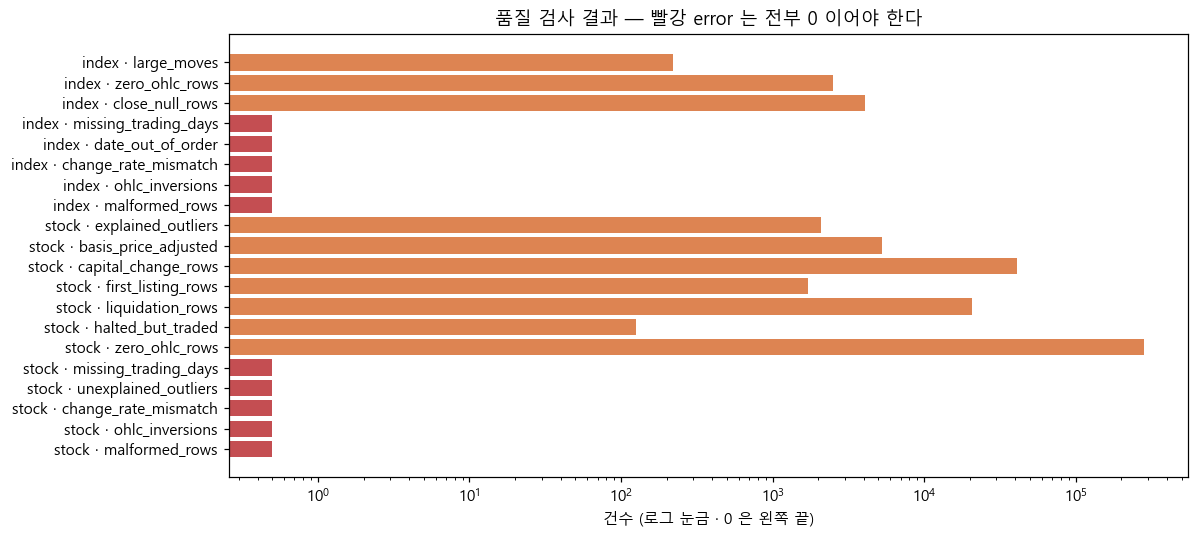

error 항목:
   구역                   항목   심각도  건수
stock       malformed_rows error   0
stock      ohlc_inversions error   0
stock change_rate_mismatch error   0
stock unexplained_outliers error   0
stock missing_trading_days error   0
index       malformed_rows error   0
index      ohlc_inversions error   0
index change_rate_mismatch error   0
index    date_out_of_order error   0
index missing_trading_days error   0


In [9]:
# 검사 항목을 심각도별로 모아 본다 — warn 은 '사실 기록' 이지 실패가 아니다
줄 = []
for 구역, 항목들 in report["sections"].items():
    for 이름, v in 항목들.items():
        줄.append({"구역": 구역, "항목": 이름,
                   "심각도": v["severity"], "건수": v["count"]})
검사 = pd.DataFrame(줄)

fig, ax = plt.subplots(figsize=(11, 5))
색 = 검사["심각도"].map({"error": "#C44E52", "warn": "#DD8452"})
ax.barh(검사["구역"] + " · " + 검사["항목"], 검사["건수"].clip(lower=0.5), color=색)
ax.set_xscale("log")
ax.set_xlabel("건수 (로그 눈금 · 0 은 왼쪽 끝)")
ax.set_title("품질 검사 결과 — 빨강 error 는 전부 0 이어야 한다", fontsize=12)
plt.tight_layout()
plt.show()

print("error 항목:")
print(검사[검사["심각도"] == "error"].to_string(index=False))

위 그림에서 **빨강(`error`)이 전부 왼쪽 끝(0건)** 이면 통과입니다.
주황(`warn`)이 큰 것은 문제가 아니라 **설명된 사실**입니다 — 거래정지 표시행 28만 건,
정리매매 2만 건처럼 자료에 실제로 그런 것이 있다는 기록입니다.

> 검사를 늘려 알람만 쌓으면 팀이 전부 무시하게 됩니다.
> 그래서 **막는 것(error)과 세는 것(warn)을 나눕니다.**


## 정리 — 매일 무엇을 보면 되나

| 순서 | 명령 | 봐야 할 것 |
|---|---|---|
| 1 | `python scripts/fetch_krx.py --days 5` | 신규 N일 · 저장 행수 |
| 2 | `python scripts/fetch_index.py --days 5` | 지수 최신일이 시세와 **같은가** |
| 3 | `python scripts/check_data.py` | `error` 다섯이 전부 0 인가 |
| 4 | `reports/data_quality.json` 의 `scale` | 어제보다 늘었나 |

이 네 줄을 **한 명령**으로 묶는 것이 `pipelines.ingest` 이고, 다음 작업입니다.
거기서는 이 노트북이 손으로 확인한 것을 **자동으로** 판정하게 만듭니다.

---

### 이 노트북에서 기억할 것

1. **행 수만 세는 검증은 덮어쓰기를 못 잡는다** — 날짜별 종목 수를 함께 본다
2. **0건에는 두 종류가 있다** — 휴장(영원히 0건)과 미확정(곧 채워짐)
3. **셋을 함께 본다** — 규모·대장·품질은 각각 다른 자리를 놓친다
4. **리포트가 DB 없는 사람의 유일한 창구다** — 그래서 규모를 남긴다


In [10]:
con.close()
print("닫았습니다.")

닫았습니다.
